###Этап 1

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import random
from collections import defaultdict
import gymnasium as gym
from IPython.display import clear_output


%matplotlib inline

In [ ]:
def my_softmax(values: np.ndarray, T=1.):
    inter = values - np.max(values)
    probas = np.exp(values/T) / np.sum(np.exp(values/T))
    return probas

In [ ]:
test_data = np.arange(5)
for temp in [0.1, 0.5, 1, 5]:
  local_softmax = my_softmax(test_data, T=temp)
  with torch.no_grad():
    torch_softmax = torch.softmax(torch.from_numpy(test_data)/temp, dim=-1)
  assert np.allclose(local_softmax, torch_softmax.numpy())
  print(f'Passed for temp={temp}')

Passed for temp=0.1
Passed for temp=0.5
Passed for temp=1
Passed for temp=5


Text(0.5, 1.0, 'Example softmax with temp = 1')

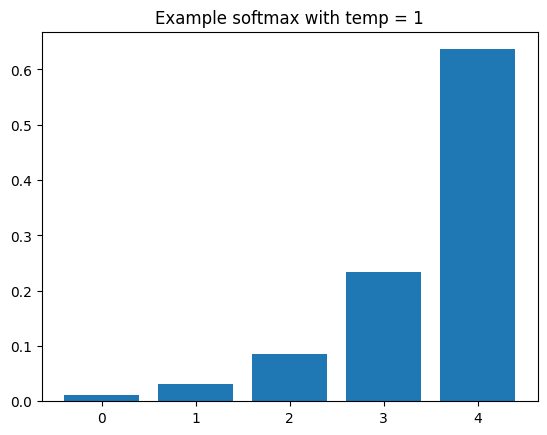

In [ ]:
temp = 1
plt.bar(test_data, my_softmax(test_data, T=temp))
plt.title(f'Example softmax with temp = {temp}')

In [ ]:
class QLearningAgent:
    def __init__(self, alpha, discount, get_legal_actions, temp=1.):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)
          - self.temp (softmax temperature)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly.
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.discount = discount
        self.temp = temp

    def get_qvalue(self, state, action):
        """Returns Q(state,action)"""
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """Sets the Qvalue for [state,action] to the given value"""
        self._qvalues[state][action] = value

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # YOUR CODE HERE
        # Calculate the approximation of value function V(s).
        Qs = list()
        for action in possible_actions:
            Qs.append(self.get_qvalue(state, action))
        value = max(Qs)

        return value

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        # YOUR CODE HERE
        # Calculate the updated value of Q(s, a).
        qvalue = (1-learning_rate)*self.get_qvalue(state, action) + learning_rate*(reward + gamma*self.get_value(next_state))

        self.set_qvalue(state, action, qvalue)

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values).
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # YOUR CODE HERE
        # Choose the best action wrt the qvalues.
        maxQ = -1000000
        maxAction = 0
        for action in possible_actions:
            if self.get_qvalue(state, action) > maxQ:
                maxQ = self.get_qvalue(state, action)
                maxAction = action
        best_action = maxAction

        return best_action

    def get_softmax_policy(self, state):
        """
        Compute all actions probabilities in the current state according
        to their q-values using softmax policy.

        Actions probability should be computed as
        p(a_i|s) = softmax([q(s, a_1), q(s, a_2), ... q(s, a_k)])_i
        Softmax temperature is set to `self.temp`.
        See the formula in the notebook for more details
        """
        possible_actions = self.get_legal_actions(state)
        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # YOUR CODE HERE
        # Compute all actions probabilities in the current state using softmax
        q_values = list()
        for action in possible_actions:
            q_values.append(self.get_qvalue(state, action))
        npQValues = np.array(q_values)
        probabilities = my_softmax(npQValues)

        return probabilities


    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.
        Select actions according to softmax policy.

        Note: To pick randomly from a list, use np.random.choice(..., p=actions_probabilities)
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """
        possible_actions = self.get_legal_actions(state)
        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # YOUR CODE HERE
        # Select the action to take in the current state according to the policy
        chosen_action = np.random.choice(possible_actions, p=self.get_softmax_policy(state))
        return chosen_action

In [ ]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

n_actions = env.action_space.n

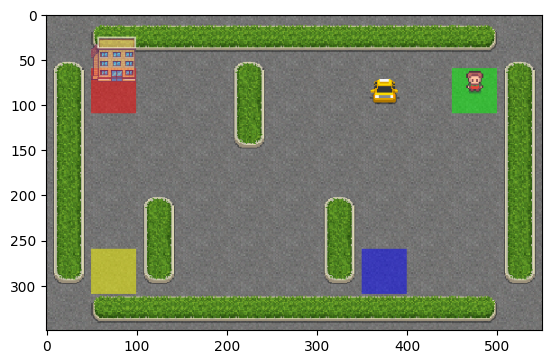

In [ ]:
s, _ = env.reset()
plt.imshow(env.render())

In [ ]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [ ]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # train (update) agent for state s
        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

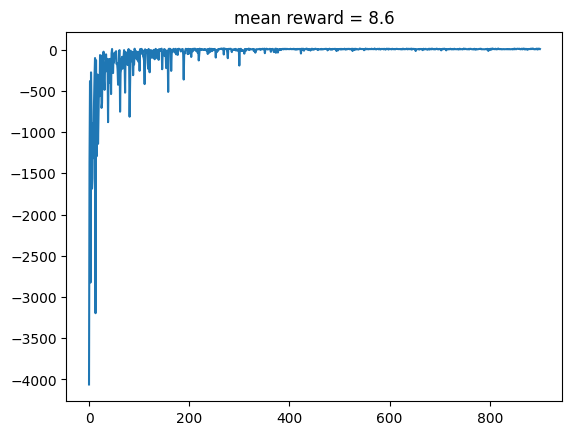

In [ ]:
rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))

    if i % 100 == 0:
        clear_output(True)
        plt.title("mean reward = {:.1f}".format(np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

###Этап 2

In [ ]:
from gymnasium.core import ObservationWrapper

first state: [ 0.0097092  -0.02860773 -0.03342098  0.04226445]


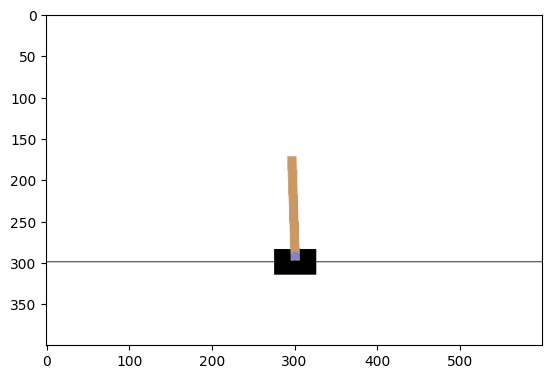

In [ ]:
def make_env():
    return gym.make("CartPole-v1", render_mode="rgb_array")


env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

In [ ]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)

    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    f, axarr = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    for i, title in enumerate(["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]):
        ax = axarr[i // 2, i % 2]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(title)
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

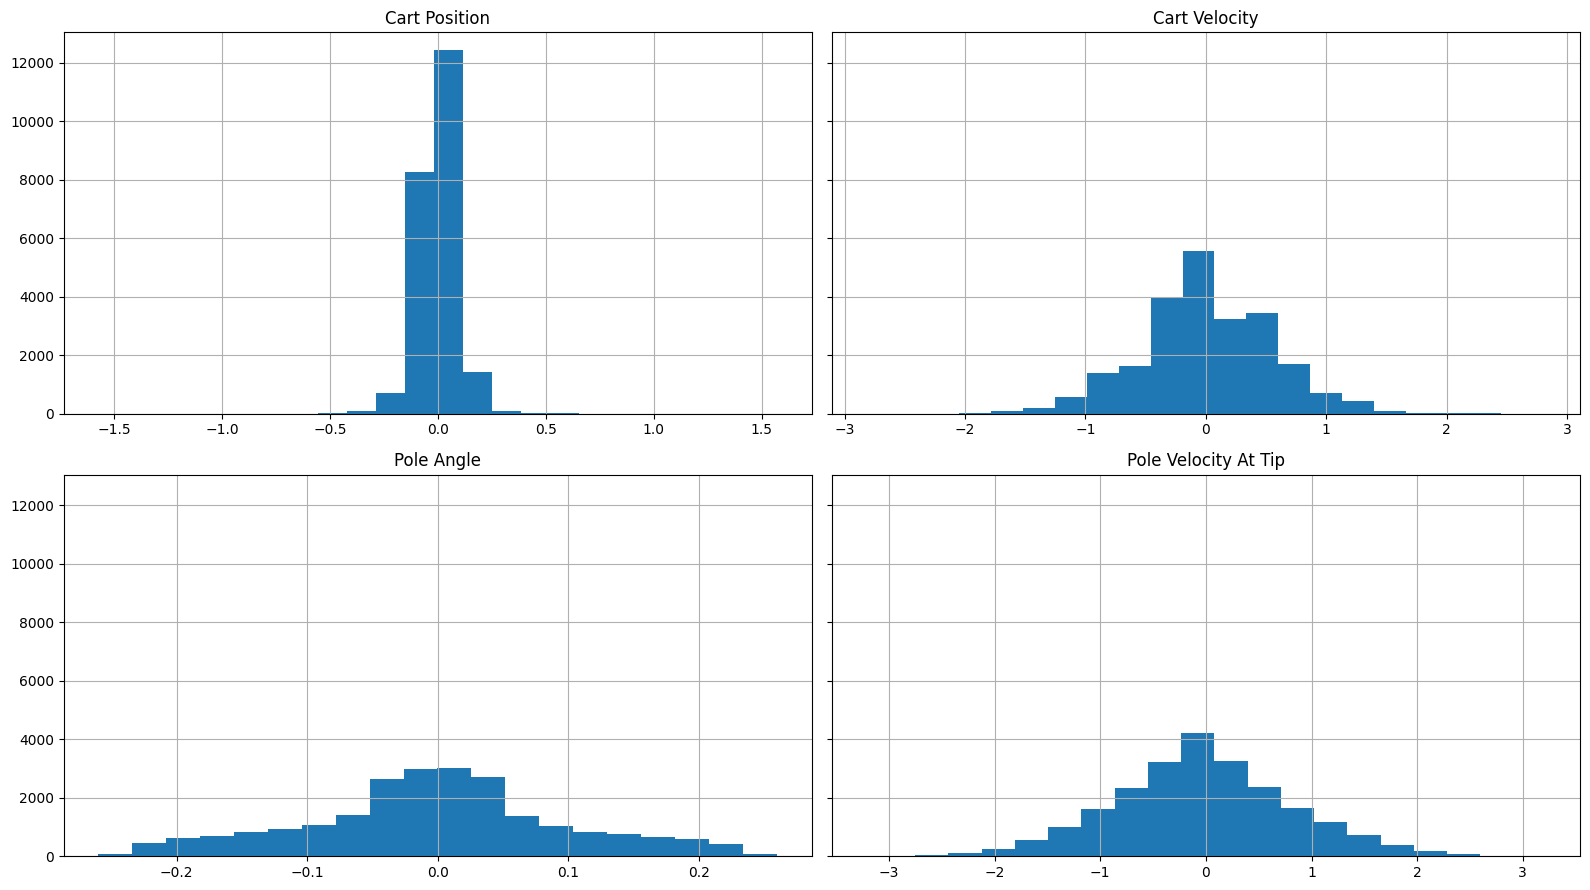

In [ ]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)

visualize_cartpole_observation_distribution(seen_observations)

In [ ]:
class Discretizer(ObservationWrapper):
    def observation(self, state):
        # Hint: you can do that with round(x, n_digits).
        # You may pick a different n_digits for each dimension.

        features_ndigits = [1, 1, 1, 1]
        for feature_index in range(len(state)):
            state[feature_index] = round(state[feature_index], features_ndigits[feature_index])

        return tuple(state)

In [ ]:
env = Discretizer(make_env())

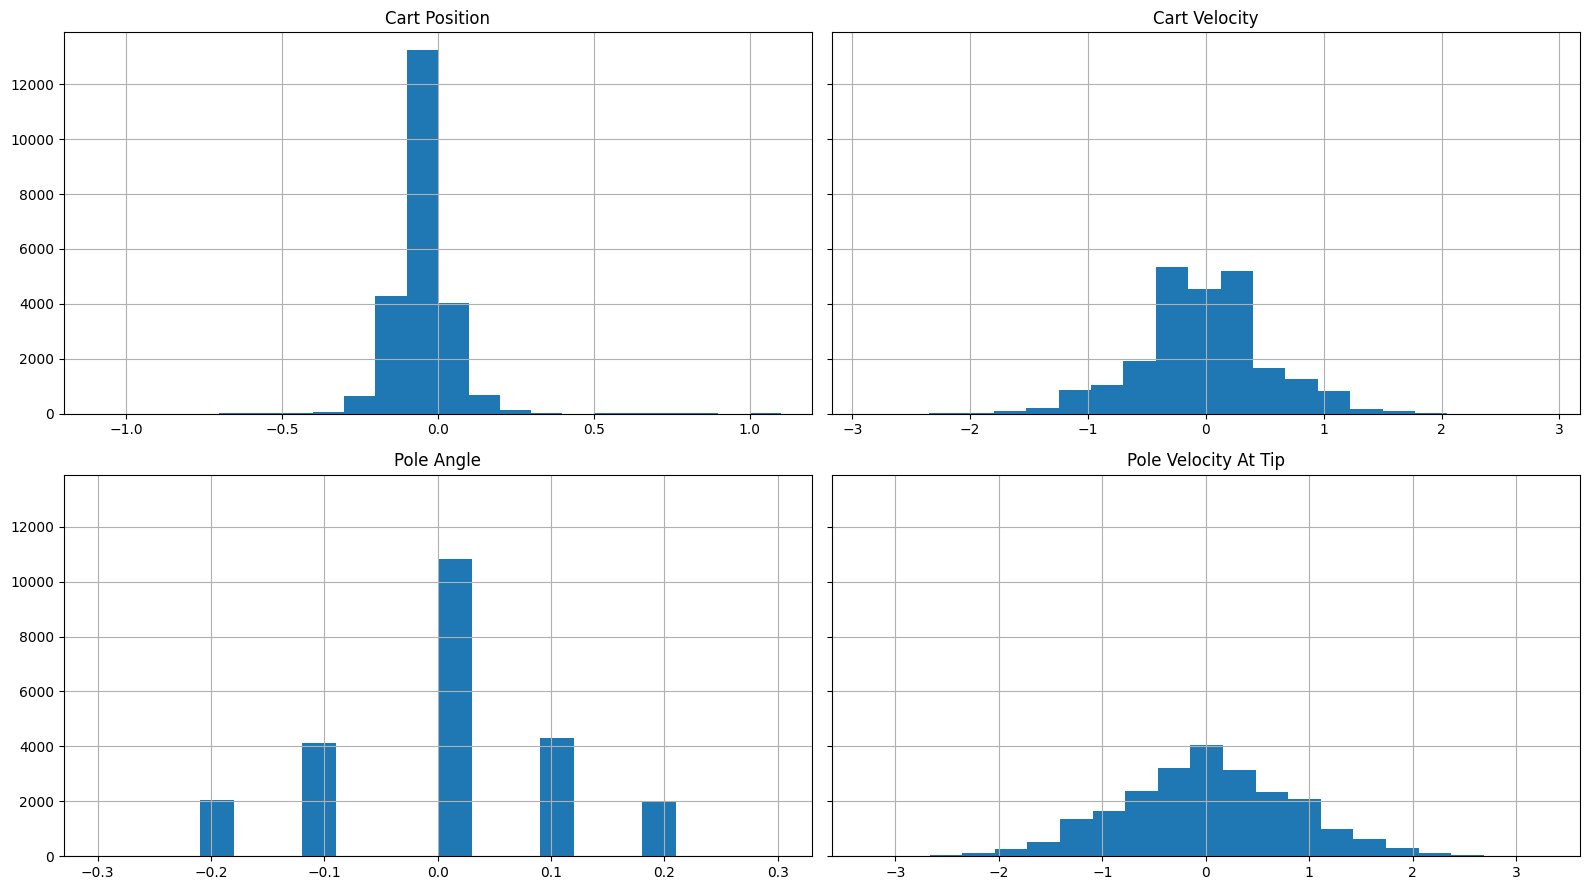

In [ ]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)
        if done:
            break

visualize_cartpole_observation_distribution(seen_observations)

In [ ]:
import pandas as pd


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values

In [ ]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [ ]:
rewards = []

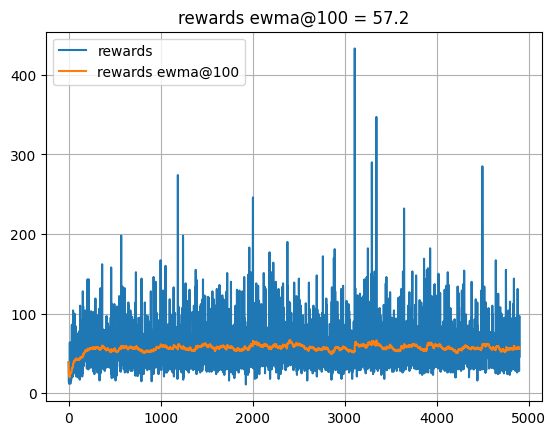

In [ ]:
for i in range(5000):
    reward = play_and_train(env, agent)
    rewards.append(reward)

    if i % 100 == 0:
        rewards_ewma = moving_average(rewards)

        clear_output(True)
        plt.plot(rewards, label="rewards")
        plt.plot(rewards_ewma, label="rewards ewma@100")
        plt.legend()
        plt.grid()
        plt.title("rewards ewma@100 = {:.1f}".format(rewards_ewma[-1]))
        plt.show()

In [ ]:
print("Your agent has learned {} Q-values.".format(len(agent._qvalues)))

Your agent has learned 6105 Q-values.


In [ ]:
class EVSarsaAgent(QLearningAgent):
    """
    An agent that changes some of q-learning functions to implement Expected Value SARSA.
    Note: this demo assumes that your implementation of QLearningAgent.update uses get_value(next_state).
    If it doesn't, please add
        def update(self, state, action, reward, next_state):
            and implement it for Expected Value SARSA's V(s')
    """

    def get_value(self, state):
        """
        Returns Vpi for current state under the softmax policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        possible_actions = self.get_legal_actions(state)
        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # YOUR CODE HERE
        # Compute the value of the current state under the softmax policy.
        value = 0
        for action in possible_actions:
            value += self.get_softmax_policy(state)[self.get_legal_actions(state).index(action)]*self.get_qvalue(state, action)
        return value

In [ ]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_actions = env.action_space.n

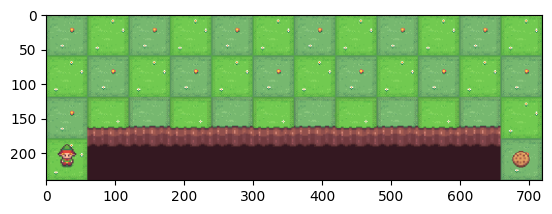

In [ ]:
# Our cliffworld has one difference from what's in the image: there is no wall.
# Agent can choose to go as close to the cliff as it wishes.
# x:start, T:exit, C:cliff, o: flat ground

env.reset()
plt.imshow(env.render())

In [ ]:
agent_sarsa = EVSarsaAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

agent_ql = QLearningAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

EVSARSA mean reward = -18.67
QLEARNING mean reward = -25.27


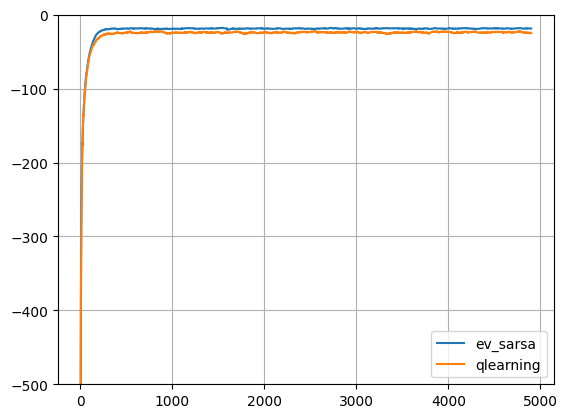

In [ ]:
from IPython.display import clear_output


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


rewards_sarsa, rewards_ql = [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))

    if i % 100 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

In [ ]:
def draw_policy(agent):
    """Prints CliffWalkingEnv policy with arrows. Hard-coded."""

    env = gym.make("CliffWalking-v1", render_mode="ansi")
    env.reset()
    grid = [x.split("  ") for x in env.render().split("\n")[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = "^>v<"

    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == "C":
                print(" C ", end="")
            elif (yi * n_cols + xi) == start_state_index:
                print(" X ", end="")
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                print(" T ", end="")
            else:
                print(" %s " % actions[agent.get_best_action(yi * n_cols + xi)], end="")
        print()

In [ ]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Q-Learning
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
SARSA
 >  >  >  >  >  >  >  >  v  v  v  v 
 >  >  >  >  >  >  >  >  >  >  v  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
